In [ ]:
#Install required packages for translation, NLP, and visualization
!pip install -q googletrans-py textblob wordcloud
!python -m textblob.download_corpora

# Import standard and NLP libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from googletrans import Translator
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Download required NLTK datasets
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

# Enable tqdm progress bar integration with pandas .apply()
tqdm.pandas()

# Load the reviews dataset
DATA_URL = "https://raw.githubusercontent.com/yashy1626/ds_dataset/refs/heads/main/reviews.csv"
df = pd.read_csv(DATA_URL, header=None, names=['review'])

print(f"✅ Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
df

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
✅ Dataset loaded successfully: 300 rows, 1 columns


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,review
0,质量很差，失望 😞
1,Sangat kecewa dengan produk ini 😞
2,Perkhidmatan pelanggan sangat baik 🙌
3,அனுப்புவதில் தாமதம் 😠
4,包装坏了，非常糟糕 👎
...,...
295,这个产品非常好！😊
296,விரைவான விநியோகம் 😊
297,விலை குறைவாக உள்ளது 👍
298,அனுப்புவதில் தாமதம் 😠


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Robust Data Cleaning

from nltk.corpus import stopwords

# Cache English stopwords for performance
STOP_WORDS = set(stopwords.words('english'))


def robust_clean_text(text):
    """
    Highly robust text cleaning pipeline.
    Steps:
      1) Translation fallback (googletrans) with try-except.
      2) Regex removal of URLs, @mentions, hashtags, numbers, special chars.
      3) Lowercasing and whitespace normalization.
      4) Stopword removal using NLTK.
      5) Spelling correction using TextBlob.
    """
    # Guard against non-string values
    if not isinstance(text, str):
        return ""

    #  1) Translation with fallback
    # Attempt to translate text to English. If the API times out or fails,
    # gracefully fall back to the original string and continue cleaning.
    try:
        translator = Translator()
        text = translator.translate(text, dest='en').text
    except Exception:
        pass  # Use original text if translation fails

    # 2) Regex-based cleaning
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (entire #word token)
    text = re.sub(r'#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters, keeping only alphabets and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3) Lowercasing & whitespace normalization
    text = text.lower().strip()

    # 4) Remove English stopwords
    words = [w for w in text.split() if w not in STOP_WORDS]
    text = ' '.join(words)

    # 5) Spelling correction with TextBlob
    if text:
        text = str(TextBlob(text).correct())

    return text


# Apply the robust cleaning function with a progress bar
print("🧹 Starting robust text cleaning (this may take a few minutes)...")
df['cleaned_review'] = df['review'].progress_apply(robust_clean_text)
print("✅ Text cleaning completed.")

# Preview original vs cleaned reviews
df[['review', 'cleaned_review']]

🧹 Starting robust text cleaning (this may take a few minutes)...


  0%|          | 0/300 [00:00<?, ?it/s]

✅ Text cleaning completed.


,review,cleaned_review
0,质量很差，失望 😞,poor quality disappointed
1,Sangat kecewa dengan produk ini 😞,disappointed product
2,Perkhidmatan pelanggan sangat baik 🙌,excellent customer service
3,அனுப்புவதில் தாமதம் 😠,delay sending
4,包装坏了，非常糟糕 👎,packing broken bad
...,...,...
295,这个产品非常好！😊,product good
296,விரைவான விநியோகம் 😊,fast delivery
297,விலை குறைவாக உள்ளது 👍,price low
298,அனுப்புவதில் தாமதம் 😠,delay sending


In [ ]:
# VADER Sentiment Scoring
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_vader_compound(text):
    """
    Calculate and return ONLY the VADER compound score.
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return sia.polarity_scores(text)['compound']

def get_vader_sentiment(compound):
    """
    Map the compound score to a sentiment label.
    """
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply VADER sentiment scoring with a progress bar
print("🧠 Calculating VADER sentiment scores...")

df['Compound'] = df['cleaned_review'].progress_apply(get_vader_compound)

df['Sentiment'] = df['Compound'].progress_apply(get_vader_sentiment)

print("✅ Sentiment scoring completed.")

# Preview cleaned reviews with their sentiment labels and compound score
display(df[['cleaned_review', 'Compound', 'Sentiment']])

🧠 Calculating VADER sentiment scores...


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

✅ Sentiment scoring completed.


,cleaned_review,Compound,Sentiment
0,poor quality disappointed,-0.7351,Negative
1,disappointed product,-0.4767,Negative
2,excellent customer service,0.5719,Positive
3,delay sending,-0.3182,Negative
4,packing broken bad,-0.7650,Negative
...,...,...,...
295,product good,0.4404,Positive
296,fast delivery,0.0000,Neutral
297,price low,-0.2732,Negative
298,delay sending,-0.3182,Negative


/tmp/ipykernel_11761/2457458826.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.countplot(data=df, x='Sentiment', palette='viridis', order=order, ax=axes[0])


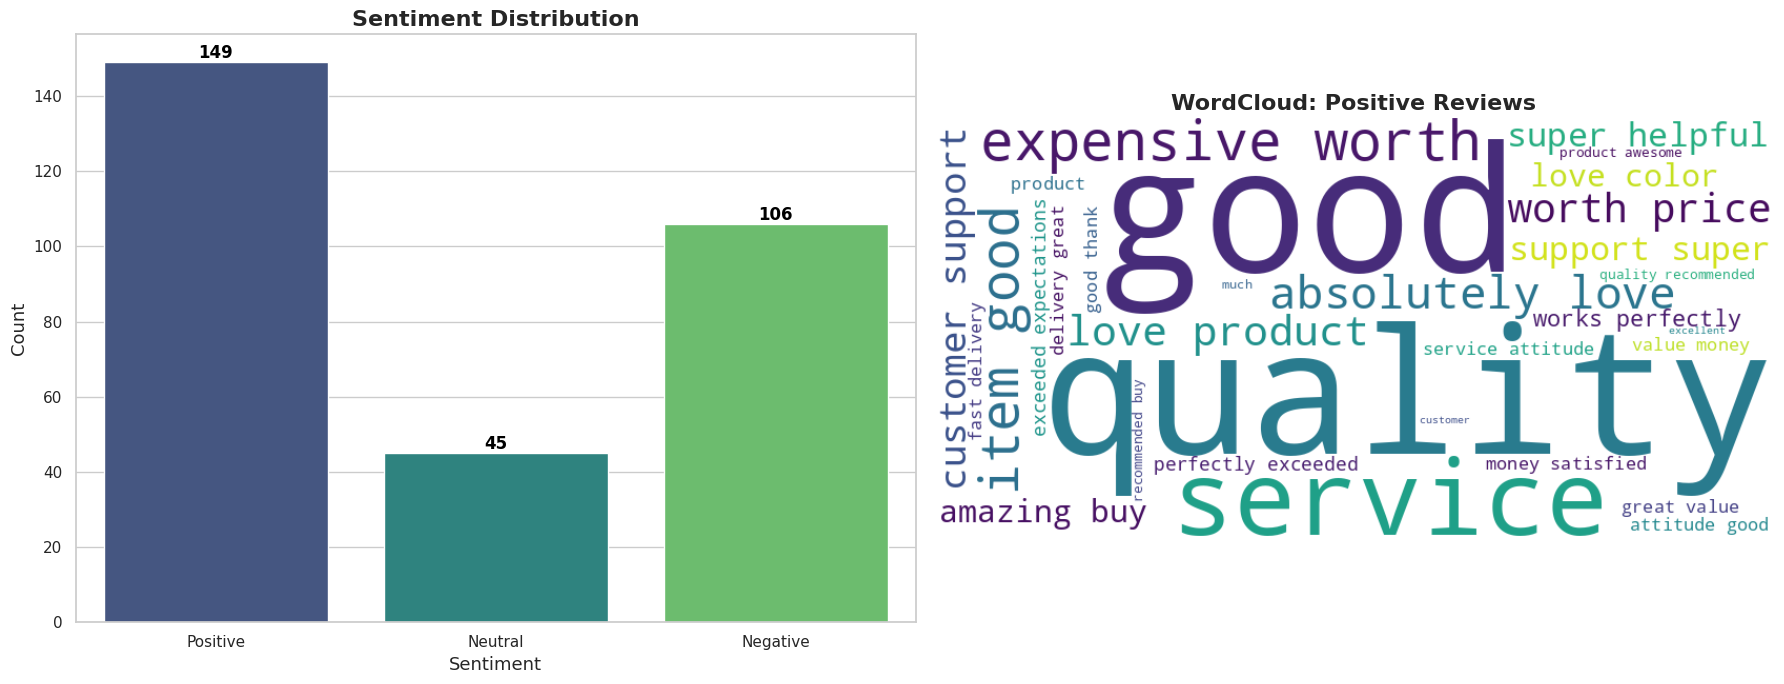

In [ ]:
# Advanced Visualizations (Side-by-Side Layout)

# Set a polished Seaborn style
sns.set_style("whitegrid")

# Create a 1x2 subplot layout (Left: Bar Chart, Right: WordCloud)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Plot: Stylish Sentiment Distribution Bar Chart
order = ['Positive', 'Neutral', 'Negative']
ax0 = sns.countplot(data=df, x='Sentiment', palette='viridis', order=order, ax=axes[0])

# Add numeric data labels on top of each bar
for p in ax0.patches:
    height = p.get_height()
    ax0.annotate(
        f'{int(height)}',
        xy=(p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

ax0.set_title('Sentiment Distribution', fontsize=16, fontweight='bold')
ax0.set_xlabel('Sentiment', fontsize=13)
ax0.set_ylabel('Count', fontsize=13)

# Right Plot: WordCloud of Positive Reviews
# Concatenate all cleaned positive reviews into one large text string
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['cleaned_review'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200,
    contour_width=1,
    contour_color='steelblue'
).generate(positive_text)

axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud: Positive Reviews', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()
